# install

In [ ]:
! pip install lightning
! pip install torchview
! pip install torchmetrics

# import

In [ ]:
# ===============================
# PyTorch Core Modules
# ===============================
import torch  # Core tensor operations
from torch import Tensor
import torch.nn as nn  # Neural network layers
import torch.nn.functional as F  # Functional API for activations, losses, etc.
import torch.optim as optim  # Optimizers
from torch.utils.data import Dataset, DataLoader, random_split  # Dataset utilities

# ===============================
# PyTorch Ecosystem
# ===============================
import pytorch_lightning as pl  # High-level training framework
import torchmetrics  # Model evaluation metrics
from torchview import draw_graph  # Model visualization
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor # Callbacks

# ===============================
# TorchVision - For image data
# ===============================
import torchvision  # Pretrained models and datasets
import torchvision.transforms as transforms  # Image preprocessing utilities
import torchvision.models as models
from torchvision.io import read_image, decode_image
from torchvision.models import resnet50, ResNet50_Weights, MobileNet_V3_Large_Weights

# ===============================
# Scikit-learn - Data generation and preprocessing
# ===============================
from sklearn.datasets import make_regression  # Synthetic regression data
from sklearn.model_selection import train_test_split  # Train/test splitting
from sklearn.preprocessing import MinMaxScaler  # Feature scaling

# ===============================
# Visualization
# ===============================
import matplotlib.pyplot as plt  # Plotting utilities

# ===============================
# Numerical Computing
# ===============================
import numpy as np  # Array operations
import math  # Basic mathematical functions

from PIL import Image
import requests
import io
import json

import os

# Dataset

## Load

In [ ]:
import kagglehub

path = kagglehub.dataset_download("yudhaislamisulistya/plants-type-datasets")

print("Path to dataset files:", path)
# %ls -R {path}

Using Colab cache for faster access to the 'plants-type-datasets' dataset.
Path to dataset files: /kaggle/input/plants-type-datasets


## PlantDataset


In [ ]:
from torchvision.io import read_image

class PlantDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = []
        self.labels = []
        self.class_to_idx = {}
        idx = 0
        for class_name in os.listdir(root_dir):
            class_dir = os.path.join(root_dir, class_name)
            if os.path.isdir(class_dir):
                self.class_to_idx[class_name] = idx
                for image_file in os.listdir(class_dir):
                    if image_file.endswith('.jpg') or image_file.endswith('.png'):
                        self.image_files.append(os.path.join(class_dir, image_file))
                        self.labels.append(idx)
                idx += 1

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = read_image(img_path).float() / 255.0 # Read as float and scale to [0, 1]
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

## transforms



In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    # transforms.ToTensor(), # Remove ToTensor as read_image already returns a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((32, 32)), # Changed from 128x128 to 32x32
    # transforms.ToTensor(), # Remove ToTensor as read_image already returns a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((32, 32)), # Changed from
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## DataLoader


In [ ]:
train_root_dir = f'{path}/split_ttv_dataset_type_of_plants/Train_Set_Folder'
val_root_dir = f'{path}/split_ttv_dataset_type_of_plants/Validation_Set_Folder'
test_root_dir = f'{path}/split_ttv_dataset_type_of_plants/Test_Set_Folder'

train_dataset = PlantDataset(root_dir=train_root_dir, transform=train_transforms)
val_dataset = PlantDataset(root_dir=val_root_dir, transform=val_transforms)
test_dataset = PlantDataset(root_dir=test_root_dir, transform=test_transforms)

batch_size = 64

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of batches in training DataLoader: {len(train_dataloader)}")
print(f"Number of batches in validation DataLoader: {len(val_dataloader)}")
print(f"Number of batches in test DataLoader: {len(test_dataloader)}")

Number of batches in training DataLoader: 375
Number of batches in validation DataLoader: 48
Number of batches in test DataLoader: 47


# Custom CNN

## simple cnn

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

class SimpleCNN_TF(models.Model):
    def __init__(self, num_classes):
        super(SimpleCNN_TF, self).__init__()
        self.conv1 = layers.Conv2D(32, (3, 3), padding='same', activation='relu')
        self.maxpool1 = layers.MaxPooling2D((2, 2), strides=(2, 2))

        self.conv2 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')
        self.maxpool2 = layers.MaxPooling2D((2, 2), strides=(2, 2))

        self.flatten = layers.Flatten()
        self.fc1 = layers.Dense(128, activation='relu')
        self.fc2 = layers.Dense(num_classes, activation='softmax') # Softmax for classification

    def call(self, x):
        x = self.conv1(x)
        x = self.maxpool1(x)
        x = self.conv2(x)
        x = self.maxpool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        return x

# Instantiate the TensorFlow CNN model
# Assuming num_classes is already defined from the dataset loading
tf_cnn_model = SimpleCNN_TF(num_classes=num_classes)

# Build the model with a dummy input shape to see the summary
# Assuming input images are 32x32 with 3 channels, similar to your PyTorch model
dummy_input_tf = tf.random.uniform((1, 32, 32, 3))
tf_cnn_model.build(input_shape=(None, 32, 32, 3)) # Batch size can be None

print("Simple CNN Model defined (TensorFlow):")
tf_cnn_model.summary()

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # First convolutional layer
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # 3 input channels, 32 output channels, 3x3 kernel
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2) # 2x2 max pooling with stride 2

        # Second convolutional layer
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 32 input channels, 64 output channels
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2) # 2x2 max pooling with stride 2

        # # Third convolutional layer
        # self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 64 input channels, 128 output channels
        # self.relu3 = nn.ReLU()
        # self.maxpool3 = nn.MaxPool2d(kernel_size=3, stride=3) # 3x3 max pooling with stride 3

        # Fully connected layers
        # The size of the input to the first fully connected layer depends on the output of the convolutional layers
        # For 32x32 images, after two conv/pool layers (kernel=2, stride=2):
        # After conv1 (3x3, p=1): size remains 32x32
        # After maxpool1 (k=2, s=2): Output size = floor((Input Size - Kernel Size) / Stride) + 1
        # Height: floor((32 - 2) / 2) + 1 = floor(30 / 2) + 1 = 15 + 1 = 16
        # Width: floor((32 - 2) / 2) + 1 = floor(30 / 2) + 1 = 15 + 1 = 16
        # Size after maxpool1 is 16x16
        # After conv2 (3x3, p=1): size remains 16x16
        # After maxpool2 (k=2, s=2): Output size = floor((Input Size - Kernel Size) / Stride) + 1
        # Height: floor((16 - 2) / 2) + 1 = floor(14 / 2) + 1 = 7 + 1 = 8
        # Width: floor((16 - 2) / 2) + 1 = floor(14 / 2) + 1 = 7 + 1 = 8
        # Size after maxpool2 is 8x8
        self.fc1 = nn.Linear(64 * 8 * 8, 128) # 64 channels * 8x8 spatial dimensions
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes) # Output layer with num_classes for classification

    def forward(self, x):
        # Apply first convolutional block
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.maxpool1(x)

        # Apply second convolutional block
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.maxpool2(x)

        # # Apply third convolutional block
        # x = self.conv3(x)
        # x = self.relu3(x)
        # x = self.maxpool3(x)


        # Flatten the tensor for the fully connected layers
        x = torch.flatten(x, 1) # Flatten starting from dimension 1 (batch dimension is 0)

        # Apply fully connected layers
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.fc2(x)

        return x

# Instantiate the CNN model
num_classes = len(train_dataset.class_to_idx)
cnn_model = SimpleCNN(num_classes=num_classes)

print("Simple CNN Model defined:")
print(cnn_model)

Simple CNN Model defined:
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (relu4): ReLU()
  (fc2): Linear(in_features=128, out_features=30, bias=True)
)


## wrapper

In [ ]:
import tensorflow as tf
import pytorch_lightning as pl
import torchmetrics

class TFPlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters() # Saves hyperparameters
        self.model = SimpleCNN_TF(num_classes) # Instantiate the TensorFlow model

        self.criterion = tf.keras.losses.CategoricalCrossentropy() # Loss function for classification
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes) # Metric for accuracy

    def forward(self, x):
        # PyTorch Lightning expects a tensor, so convert TensorFlow output to tensor
        return torch.tensor(self.model(x).numpy())


    def training_step(self, batch, batch_idx):
        images, labels = batch
        # Convert PyTorch tensors to TensorFlow tensors
        images_tf = tf.convert_to_tensor(images.permute(0, 2, 3, 1).numpy()) # Convert from (B, C, H, W) to (B, H, W, C)
        labels_tf = tf.convert_to_tensor(labels.numpy())

        with tf.GradientTape() as tape:
            outputs = self.model(images_tf)
            # Convert labels to one-hot encoding for CategoricalCrossentropy
            labels_one_hot = tf.one_hot(labels_tf, depth=self.hparams.num_classes)
            loss = self.criterion(labels_one_hot, outputs)

        # Apply gradients manually since we are using a TF model in a PL module
        optimizer = self.optimizers()
        gradients = tape.gradient(loss, self.model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, self.model.trainable_variables))


        self.log('train_loss', loss.numpy()) # Log TensorFlow loss
        # Convert TensorFlow outputs and labels back to PyTorch tensors for torchmetrics
        self.log('train_acc', self.accuracy(torch.tensor(outputs.numpy()), labels))
        return loss.numpy()

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        # Convert PyTorch tensors to TensorFlow tensors
        images_tf = tf.convert_to_tensor(images.permute(0, 2, 3, 1).numpy()) # Convert from (B, C, H, W) to (B, H, W, C)
        labels_tf = tf.convert_to_tensor(labels.numpy())

        outputs = self.model(images_tf)
        labels_one_hot = tf.one_hot(labels_tf, depth=self.hparams.num_classes)
        loss = self.criterion(labels_one_hot, outputs)


        self.log('val_loss', loss.numpy()) # Log TensorFlow loss
        # Convert TensorFlow outputs and labels back to PyTorch tensors for torchmetrics
        self.log('val_acc', self.accuracy(torch.tensor(outputs.numpy()), labels))
        return loss.numpy()

    def test_step(self, batch, batch_idx):
        images, labels = batch
        # Convert PyTorch tensors to TensorFlow tensors
        images_tf = tf.convert_to_tensor(images.permute(0, 2, 3, 1).numpy()) # Convert from (B, C, H, W) to (B, H, W, C)
        labels_tf = tf.convert_to_tensor(labels.numpy())

        outputs = self.model(images_tf)
        labels_one_hot = tf.one_hot(labels_tf, depth=self.hparams.num_classes)
        loss = self.criterion(labels_one_hot, outputs)

        self.log('test_loss', loss.numpy()) # Log TensorFlow loss
        # Convert TensorFlow outputs and labels back to PyTorch tensors for torchmetrics
        self.log('test_acc', self.accuracy(torch.tensor(outputs.numpy()), labels))
        return loss.numpy()


    def configure_optimizers(self):
        # Use a TensorFlow optimizer
        optimizer = tf.keras.optimizers.Adam(learning_rate=self.hparams.learning_rate)
        return optimizer

# Instantiate the Lightning Module with the TensorFlow model
num_classes = len(train_dataset.class_to_idx)
tf_lightning_model = TFPlantClassifierLightningModule(num_classes=num_classes)

print("TensorFlow Plant Classifier Lightning Module defined.")
print(tf_lightning_model)

In [ ]:
class PlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters() # Saves hyperparameters like num_classes and learning_rate
        self.model = SimpleCNN(num_classes) # Our CNN model
        self.criterion = nn.CrossEntropyLoss() # Loss function for classification
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes) # Metric for accuracy

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss)
        self.log('train_acc', self.accuracy(outputs, labels))
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss)
        self.log('val_acc', self.accuracy(outputs, labels))
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        return loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return optimizer

# Instantiate the Lightning Module
num_classes = len(train_dataset.class_to_idx)
lightning_model = PlantClassifierLightningModule(num_classes=num_classes)

print("Plant Classifier Lightning Module defined.")
print(lightning_model)


Plant Classifier Lightning Module defined.
PlantClassifierLightningModule(
  (model): SimpleCNN(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu1): ReLU()
    (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu2): ReLU()
    (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (fc1): Linear(in_features=4096, out_features=128, bias=True)
    (relu4): ReLU()
    (fc2): Linear(in_features=128, out_features=30, bias=True)
  )
  (criterion): CrossEntropyLoss()
  (accuracy): MulticlassAccuracy()
)


## model graph

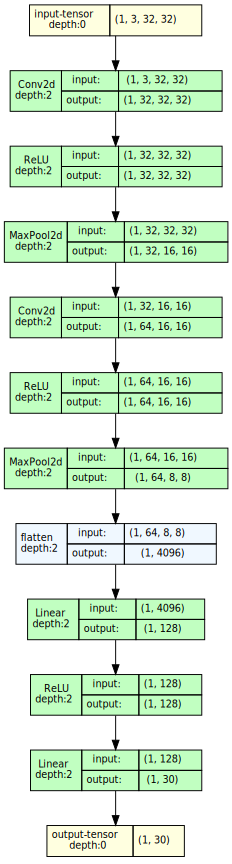

In [ ]:
# Instantiate the Lightning Module
# We need to provide the same parameters as when it was defined
# num_classes = len(train_dataset.class_to_idx)
# lightning_model_for_graph = PlantClassifierLightningModule(num_classes=num_classes)

# # Create a dummy input tensor for PlantDataset images (224x224)
# dummy_input_plant = torch.randn(1, 3, 32, 32)

# # Use draw_graph to visualize the PlantClassifierLightningModule
# plant_model_graph = draw_graph(
#     model=lightning_model_for_graph,
#     input_data=dummy_input_plant,
#     graph_name='Plant Dataset Lightning Module Visualization', # Name for the generated graph
#     # Set depth to a higher value if you want to see more nested modules
#     depth=3 # Adjust this to see more or less detail of the nested SimpleCNN
# )

# # Display the visual graph
# plant_model_graph.visual_graph

## train

In [ ]:
# Model Checkpoint Callback
# Saves the model's weights based on a monitored metric (e.g., validation accuracy)
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc', # Metric to monitor
    mode='max',        # 'max' means we want to maximize the monitored metric
    dirpath='checkpoints/', # Directory to save checkpoints
    filename='best-plant-model', # Name for the checkpoint file
    save_top_k=1,      # Save only the best model based on the monitored metric
    verbose=True       # Print a message when a checkpoint is saved
)

# Early Stopping Callback
# Stops training early if the mbaonitored metric doesn't improve for a certain number of epochs
early_stopping_callback = EarlyStopping(
    monitor='val_loss', # Metric to monitor
    mode='min',         # 'min' means we want to minimize the monitored metric
    patience=3,         # Number of epochs with no improvement after which training will be stopped
    verbose=True        # Print a message when early stopping is triggered
)

# Learning Rate Monitor Callback
# Logs the learning rate during training. Useful for learning rate scheduling.
lr_monitor_callback = LearningRateMonitor(logging_interval='step') # Log learning rate at each step

# Instantiate the PyTorch Lightning Trainer
# You can configure various options here, e.g., gpus, max_epochs, etc.
trainer = pl.Trainer(
    max_epochs=10, # Train for a few more epochs to see callbacks in action
    accelerator='auto', # Use GPU if available, otherwise CPU
    devices=1,  # Use 1 device (GPU or CPU)
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback] # Pass the list of callbacks to the Trainer
)

# Start Training
print("Starting Plant Dataset training with callbacks...")
trainer.fit(tf_lightning_model, train_dataloader, val_dataloader)

# Test the model after training
print("\nStarting Plant Dataset testing...")

# For simplicity here, we just test the model in its final state after training
trainer.test(tf_lightning_model, test_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | SimpleCNN          | 547 K  | train
1 | criterion | CrossEntropyLoss   | 0      | train
2 | accuracy  | MulticlassAccuracy | 0      | train
---------------------------------------------------------
547 K     Trainable params
0         Non-trainable params
547 K     Total params
2.191     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Starting Plant Dataset training with callbacks...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:Epoch 9, global step 3750: 'val_acc' was not in top 1
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Starting Plant Dataset testing...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.6377584934234619     │
│         test_loss         │    1.0929358005523682     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.0929358005523682, 'test_acc': 0.6377584934234619}]